<a href="https://colab.research.google.com/github/LaraDondossola/Classificacao-eventos-climaticos/blob/main/Notebooks/Limpeza-e-Pr%C3%A9-processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# 1. Importações e Carga dos Dados
from pathlib import Path
import pandas as pd
import numpy as np

# Configuração de diretórios
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Lendo o dataset
FILE_PATH = "Danos_Informados.xlsx" # Ou RAW_DIR / "Danos_Informados.xlsx"
df_raw = pd.read_excel(FILE_PATH)

print("Dimensão da base bruta:", df_raw.shape)
df_raw.head(3)

Dimensão da base bruta: (6038, 53)


,UF,Município,Registro,Protocolo,COBRADE,Status,População,DH_Mortos,DH_Feridos,DH_Enfermos,...,PEPL_Telecomunicações (R$),"PEPL_Transportes locais, regionais e de longo curso (R$)","PEPL_Distribuição de combustíveis, especialmente os de uso doméstico (R$)",PEPL_Segurança pública (R$),PEPL_Ensino (R$),PEPR_Agricultura (R$),PEPR_Pecuária (R$),PEPR_Indústria (R$),PEPR_Comércio (R$),PEPR_Serviços (R$)
0,SP,Caieiras,31/12/2024,SP-F-3509007-13214-20241230,13214 - Tempestade Local/Convectiva - Chuvas I...,Reconhecido,86623.0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,PE,Caruaru,02/01/2025,PE-F-2604106-14131-20241230,14131 - Incêndio Florestal - Incêndios em Parq...,Registro,314951.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MG,Rio Preto,31/12/2024,MG-F-3155900-13214-20241230,13214 - Tempestade Local/Convectiva - Chuvas I...,Reconhecido,5292.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,10000.0,10000.0,150000.0,0.0,0.0


In [14]:
# 2. Inspeção Estrutural
print("Total de duplicatas exatas iniciais:", df_raw.duplicated().sum())
print("Total de colunas:", len(df_raw.columns))
print("Colunas da base:", df_raw.columns.tolist()[:10], "...")

Total de duplicatas exatas iniciais: 6
Total de colunas: 53
Colunas da base: ['UF', 'Município', 'Registro', 'Protocolo', 'COBRADE', 'Status', 'População', 'DH_Mortos', 'DH_Feridos', 'DH_Enfermos'] ...


In [15]:
# 3. Higiene Mínima Determinística
dados = df_raw.copy()

# 1. Remoção de duplicatas exatas
dados = dados.drop_duplicates().reset_index(drop=True)

# 2. Padronização de textos e datas
dados['UF'] = dados['UF'].astype(str).str.strip().str.upper()
dados['Município'] = dados['Município'].astype(str).str.strip()
dados['Registro'] = pd.to_datetime(dados['Registro'], dayfirst=True, errors='coerce')

# Trimming para evitar categorias inconsistentes no OneHotEncoder
for col in ['COBRADE', 'Status']:
    if col in dados.columns:
        dados[col] = dados[col].astype(str).str.strip()

print("Duplicatas restantes:", dados.duplicated().sum())
print("Dimensão após higiene:", dados.shape)

Duplicatas restantes: 0
Dimensão após higiene: (6032, 53)


In [16]:
# 3. Split Temporal (Isolamento do Teste Sagrado)
dados = dados.sort_values("Registro").reset_index(drop=True)

n = len(dados)
fim_treino = int(n * 0.70)
fim_validacao = int(n * 0.85)

train = dados.iloc[:fim_treino].copy()
val = dados.iloc[fim_treino:fim_validacao].copy()
test = dados.iloc[fim_validacao:].copy()

print(f"Treino: {train.shape} | Período: {train['Registro'].min().strftime('%d/%m/%Y')} a {train['Registro'].max().strftime('%d/%m/%Y')}")
print(f"Validação: {val.shape} | Período: {val['Registro'].min().strftime('%d/%m/%Y')} a {val['Registro'].max().strftime('%d/%m/%Y')}")
print(f"Teste: {test.shape} | Período: {test['Registro'].min().strftime('%d/%m/%Y')} a {test['Registro'].max().strftime('%d/%m/%Y')}")

Treino: (4222, 53) | Período: 01/01/2024 a 09/09/2024
Validação: (905, 53) | Período: 09/09/2024 a 18/10/2024
Teste: (905, 53) | Período: 18/10/2024 a 11/06/2025


In [17]:
# 4. Checagem de Esquema e Quarentena
COLUNAS_OBRIGATORIAS = ['UF', 'Município', 'População', 'COBRADE', 'Registro']

def separar_quarentena(base):
    faltantes = [c for c in COLUNAS_OBRIGATORIAS if c not in base.columns]
    if faltantes:
        raise ValueError(f"Colunas obrigatórias ausentes: {faltantes}")

    pop_invalida = (base['População'] < 0)
    data_invalida = base['Registro'].isna()

    mascara_invalida = pop_invalida | data_invalida

    quarentena = base.loc[mascara_invalida].copy()
    valido = base.loc[~mascara_invalida].copy()

    return valido, quarentena

train_ok, q_train = separar_quarentena(train)
val_ok, q_val = separar_quarentena(val)
test_ok, q_test = separar_quarentena(test)

print("Registros na Quarentena - Treino:", len(q_train))
print("Registros na Quarentena - Validação:", len(q_val))
print("Registros na Quarentena - Teste:", len(q_test))

Registros na Quarentena - Treino: 0
Registros na Quarentena - Validação: 0
Registros na Quarentena - Teste: 0


In [18]:
# 5. Engenharia de Atributos e Construção dos Targets
COLUNAS_DANOS_HUMANOS = [
    'DH_Mortos', 'DH_Feridos', 'DH_Enfermos',
    'DH_Desabrigados', 'DH_Desalojados', 'DH_Desaparecidos', 'DH_Outros Afetados'
]

def extrair_tipo_evento(cobrade):
    """ Extrai o nome/tipo do evento da coluna COBRADE (ex: '13214 - Tempestade Local...' -> 'Tempestade Local/Convectiva') """
    if pd.isna(cobrade) or not str(cobrade).strip():
        return 'Outros'
    partes = str(cobrade).split('-')
    if len(partes) >= 2:
        return partes[1].strip()
    return str(cobrade).strip()

def criar_features_e_targets(df_base):
    df_out = df_base.copy()

    # Target de Regressão: Volume Total de Pessoas Afetadas
    df_out['Total_Afetados'] = df_out[COLUNAS_DANOS_HUMANOS].fillna(0).sum(axis=1)

    # Target de Classificação: Nível de Risco (Baixo, Médio, Alto)
    df_out['Nivel_Risco'] = pd.cut(
        df_out['Total_Afetados'],
        bins=[-np.inf, 10, 1000, np.inf],
        labels=['Baixo', 'Médio', 'Alto']
    )

    # Novas Features Categóricas e Temporais
    df_out['Tipo_Evento'] = df_out['COBRADE'].apply(extrair_tipo_evento)
    df_out['Mes_Registro'] = df_out['Registro'].dt.month
    df_out['Trimestre'] = df_out['Registro'].dt.quarter

    return df_out

train_fe = criar_features_e_targets(train_ok)
val_fe = criar_features_e_targets(val_ok)
test_fe = criar_features_e_targets(test_ok)

print("Atributos 'Tipo_Evento', 'UF' e 'Total_Afetados' prontos!")
train_fe[['Registro', 'UF', 'COBRADE', 'Tipo_Evento', 'Total_Afetados', 'Nivel_Risco']].head(3)

Atributos 'Tipo_Evento', 'UF' e 'Total_Afetados' prontos!


,Registro,UF,COBRADE,Tipo_Evento,Total_Afetados,Nivel_Risco
0,2024-01-01,RN,11410 - Erosão Costeira/Marinha,Erosão Costeira/Marinha,0.0,Baixo
1,2024-01-01,RN,11432 - Erosão Continental - Ravinas,Erosão Continental,0.0,Baixo
2,2024-01-03,RS,13213 - Tempestade Local/Convectiva - Granizo,Tempestade Local/Convectiva,0.0,Baixo


In [19]:
# 6. Pipeline de Pré-Processamento (Tratamento de Outliers e Feature Encoding)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Realiza Winsorization (Clipping) nos dados numéricos baseado nos quantis aprendidos no FIT.
    Impede que valores discrepantes (outliers) distorçam a padronização sem gerar Data Leakage.
    """
    def __init__(self, lower_quantile=0.0, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_bounds_ = X_df.quantile(self.lower_quantile).values
        self.upper_bounds_ = X_df.quantile(self.upper_quantile).values
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1).values

features_numericas = [
    'População', 'Mes_Registro', 'Trimestre',
    'DM_Unidades Habitacionais Danificadas', 'DM_Unidades Habitacionais Destruídas',
    'DM_Obras de infraestrutura pública Danificadas'
]

# Inclusão explícita de UF e Tipo_Evento como Preditores
features_categoricas = ['UF', 'Tipo_Evento']

# Pipeline com Imputação, Capper de Outliers e Normalização
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(lower_quantile=0.0, upper_quantile=0.99)),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', pipeline_numerico, features_numericas),
    ('cat', pipeline_categorico, features_categoricas)
])

# Seleção dos preditores
X_train = train_fe[features_numericas + features_categoricas]
X_val = val_fe[features_numericas + features_categoricas]
X_test = test_fe[features_numericas + features_categoricas]

# Fit APENAS no Treino / Transform em Validação e Teste
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Dimensão dos dados processados de Treino:", X_train_processed.shape)
print("Dimensão dos dados processados de Validação:", X_val_processed.shape)
print("Dimensão dos dados processados de Teste:", X_test_processed.shape)

Dimensão dos dados processados de Treino: (4222, 65)
Dimensão dos dados processados de Validação: (905, 65)
Dimensão dos dados processados de Teste: (905, 65)


In [20]:
# 7. Exportação dos Datasets Tratados
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_fe.to_parquet(PROCESSED_DIR / "train_processed.parquet", index=False)
val_fe.to_parquet(PROCESSED_DIR / "val_processed.parquet", index=False)
test_fe.to_parquet(PROCESSED_DIR / "test_processed.parquet", index=False)

print(f"Bases de Treino, Validação e Teste exportadas com sucesso para {PROCESSED_DIR}")

Bases de Treino, Validação e Teste exportadas com sucesso para data/processed


In [21]:
# 8. Treinamento de Modelos
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Targets de Treino
y_train_reg = train_fe['Total_Afetados']
y_train_clf = train_fe['Nivel_Risco']

# 1. Regressão
modelo_reg_ridge = Ridge(alpha=1.0)
modelo_reg_ridge.fit(X_train_processed, y_train_reg)

modelo_reg_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelo_reg_rf.fit(X_train_processed, y_train_reg)

# 2. Classificação Multiclasse
modelo_clf_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_clf_lr.fit(X_train_processed, y_train_clf)

modelo_clf_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_clf_rf.fit(X_train_processed, y_train_clf)

print("Modelos de Regressão e Classificação treinados com sucesso!")

Modelos de Regressão e Classificação treinados com sucesso!


In [22]:
# 9. Avaliação e Comparação de Modelos
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, classification_report
)

y_test_reg = test_fe['Total_Afetados']
y_test_clf = test_fe['Nivel_Risco']

# --- 1. REGRESSÃO ---
def avaliar_regressao(nome, modelo):
    y_pred = modelo.predict(X_test_processed)
    return {
        'Modelo': nome,
        'RMSE': np.round(np.sqrt(mean_squared_error(y_test_reg, y_pred)), 2),
        'MAE': np.round(mean_absolute_error(y_test_reg, y_pred), 2),
        'R2': np.round(r2_score(y_test_reg, y_pred), 4)
    }

df_reg = pd.DataFrame([
    avaliar_regressao("Ridge Regression", modelo_reg_ridge),
    avaliar_regressao("Random Forest Regressor", modelo_reg_rf)
])

print("=== TABELA COMPARATIVA - REGRESSÃO ===")
display(df_reg)

# --- 2. CLASSIFICAÇÃO ---
def avaliar_classificacao(nome, modelo):
    y_pred = modelo.predict(X_test_processed)
    return {
        'Modelo': nome,
        'Acurácia': np.round(accuracy_score(y_test_clf, y_pred), 4),
        'F1-Score (Macro)': np.round(f1_score(y_test_clf, y_pred, average='macro'), 4)
    }

df_clf = pd.DataFrame([
    avaliar_classificacao("Logistic Regression", modelo_clf_lr),
    avaliar_classificacao("Random Forest Classifier", modelo_clf_rf)
])

print("\n=== TABELA COMPARATIVA - CLASSIFICAÇÃO ===")
display(df_clf)

# --- 3. RELATÓRIO DETALHADO ---
print("\n=== CLASSIFICATION REPORT (Random Forest) ===")
print(classification_report(y_test_clf, modelo_clf_rf.predict(X_test_processed)))

=== TABELA COMPARATIVA - REGRESSÃO ===


,Modelo,RMSE,MAE,R2
0,Ridge Regression,83737.37,15097.36,0.0472
1,Random Forest Regressor,81672.26,11840.74,0.0937



=== TABELA COMPARATIVA - CLASSIFICAÇÃO ===


,Modelo,Acurácia,F1-Score (Macro)
0,Logistic Regression,0.5359,0.4698
1,Random Forest Classifier,0.6630,0.5207



=== CLASSIFICATION REPORT (Random Forest) ===
              precision    recall  f1-score   support

        Alto       0.60      0.93      0.73       358
       Baixo       0.79      0.62      0.69       417
       Médio       0.50      0.08      0.14       130

    accuracy                           0.66       905
   macro avg       0.63      0.54      0.52       905
weighted avg       0.67      0.66      0.63       905



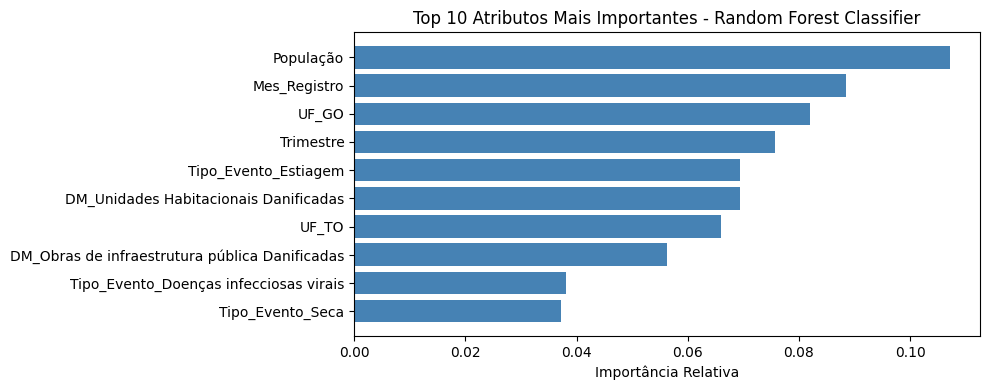

In [23]:
# 10. Análise de Feature Importance
import matplotlib.pyplot as plt

# Nomes atualizados das colunas categóricas após OneHotEncoder
cat_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(features_categoricas)
nomes_features = features_numericas + list(cat_cols)

importancias = modelo_clf_rf.feature_importances_
df_imp = pd.DataFrame({'Atributo': nomes_features, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 4))
plt.barh(df_imp['Atributo'], df_imp['Importancia'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Atributos Mais Importantes - Random Forest Classifier")
plt.xlabel("Importância Relativa")
plt.tight_layout()
plt.show()

In [24]:
import joblib
from google.colab import files
from pathlib import Path

# 1. Definir e criar pasta de destino para os modelos salvos
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 2. Salvar o Pré-processador (ColumnTransformer)
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.joblib")

# 3. Salvar os Modelos de Regressão
joblib.dump(modelo_reg_ridge, MODELS_DIR / "modelo_reg_ridge.joblib")
joblib.dump(modelo_reg_rf, MODELS_DIR / "modelo_reg_rf.joblib")

# 4. Salvar os Modelos de Classificação
joblib.dump(modelo_clf_lr, MODELS_DIR / "modelo_clf_lr.joblib")
joblib.dump(modelo_clf_rf, MODELS_DIR / "modelo_clf_rf.joblib")

print(f"✅ Todos os modelos e pré-processador foram salvos na pasta '{MODELS_DIR}'!\n")

# 5. Baixar os arquivos automaticamente para o computador
arquivos_para_baixar = [
    MODELS_DIR / "preprocessor.joblib",
    MODELS_DIR / "modelo_reg_ridge.joblib",
    MODELS_DIR / "modelo_reg_rf.joblib",
    MODELS_DIR / "modelo_clf_lr.joblib",
    MODELS_DIR / "modelo_clf_rf.joblib"
]

for arquivo in arquivos_para_baixar:
    files.download(str(arquivo))

✅ Todos os modelos e pré-processador foram salvos na pasta 'models'!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>